# Loan Prediction – Advanced Analysis, Statistical Testing & Feature Engineering
Week 3 – AnalystLab Africa Data Science Internship

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
COLORS = ["#4C72B0", "#DD8452"]
pd.set_option("display.max_columns", None)

## Part 1 – Review of Week 2 Dataset

In [2]:
df = pd.read_csv("../data/processed/loan_cleaned.csv")
df.shape

(614, 13)

In [3]:
df.isnull().sum().sum(), df.duplicated().sum()

(np.int64(0), np.int64(1))

In [4]:
df["Loan_Status"].value_counts(normalize=True).round(3)

Loan_Status
Y    0.687
N    0.313
Name: proportion, dtype: float64

## Part 2 – Advanced Exploratory Data Analysis

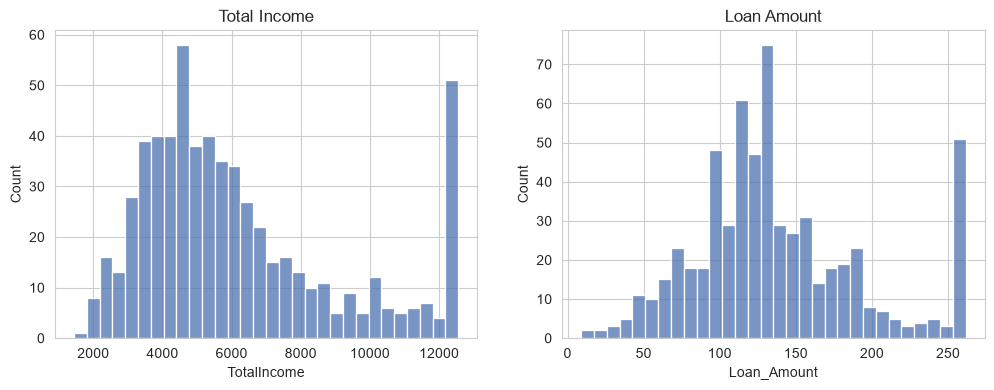

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["TotalIncome"], bins=30, color=COLORS[0], ax=axes[0])
sns.histplot(df["Loan_Amount"], bins=30, color=COLORS[0], ax=axes[1])
axes[0].set_title("Total Income")
axes[1].set_title("Loan Amount")
plt.savefig("../visuals/01_distributions.png", bbox_inches="tight")
plt.show()

In [6]:
print("Skewness — TotalIncome:", df["TotalIncome"].skew().round(2))
print("Skewness — Loan_Amount:", df["Loan_Amount"].skew().round(2))

Skewness — TotalIncome: 0.94
Skewness — Loan_Amount: 0.68


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_32112\839429436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Loan_Status", y="TotalIncome", palette=COLORS, ax=axes[0])
C:\Users\Administrateur\AppData\Local\Temp\ipykernel_32112\839429436.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Loan_Status", y="Loan_Amount", palette=COLORS, ax=axes[1])


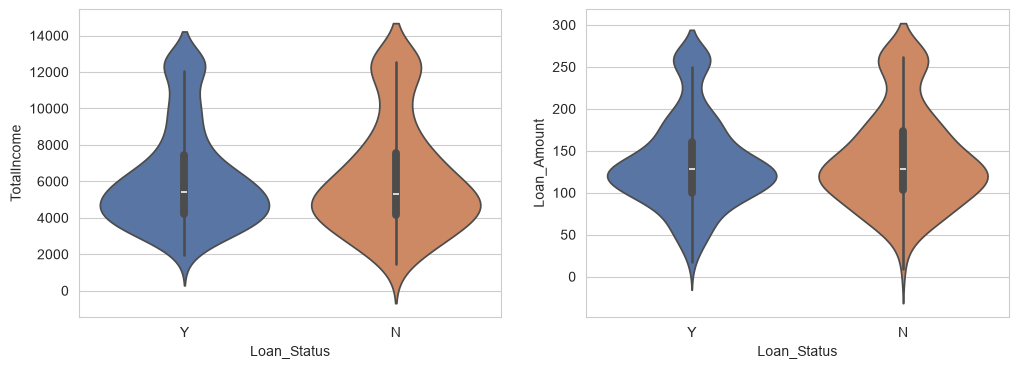

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.violinplot(data=df, x="Loan_Status", y="TotalIncome", palette=COLORS, ax=axes[0])
sns.violinplot(data=df, x="Loan_Status", y="Loan_Amount", palette=COLORS, ax=axes[1])
plt.savefig("../visuals/02_violin_by_status.png", bbox_inches="tight")
plt.show()

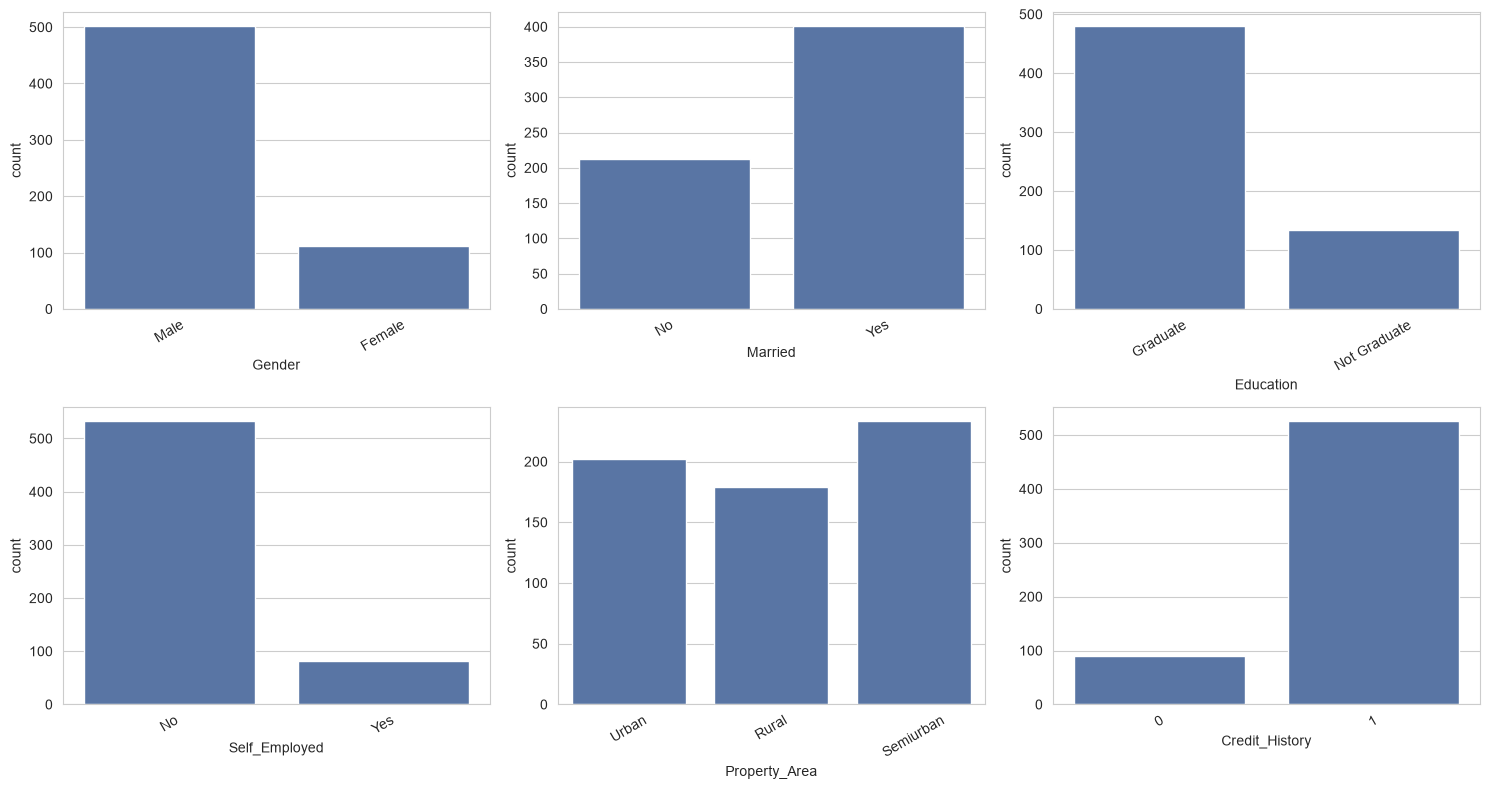

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cat_cols = ["Gender", "Married", "Education", "Self_Employed", "Property_Area", "Credit_History"]
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=df, x=col, ax=ax, color=COLORS[0])
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("../visuals/03_categorical_frequencies.png", bbox_inches="tight")
plt.show()

In [9]:
pd.crosstab(df["Property_Area"], df["Loan_Status"], normalize="index").round(3) * 100

Loan_Status,N,Y
Property_Area,,
Rural,38.5,61.5
Semiurban,23.2,76.8
Urban,34.2,65.8


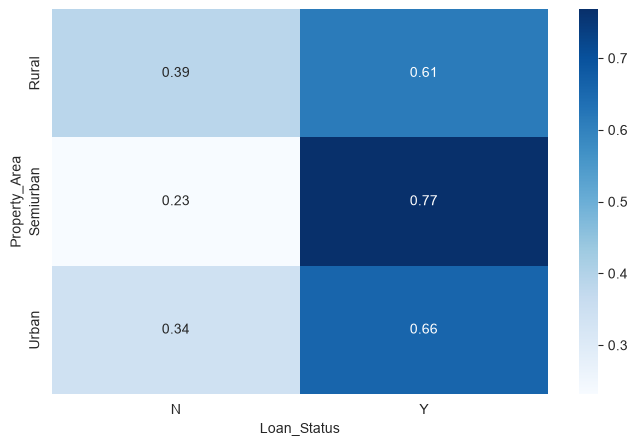

In [10]:
plt.figure()
sns.heatmap(pd.crosstab(df["Property_Area"], df["Loan_Status"], normalize="index"), annot=True, fmt=".2f", cmap="Blues")
plt.savefig("../visuals/04_crosstab_property_area.png", bbox_inches="tight")
plt.show()

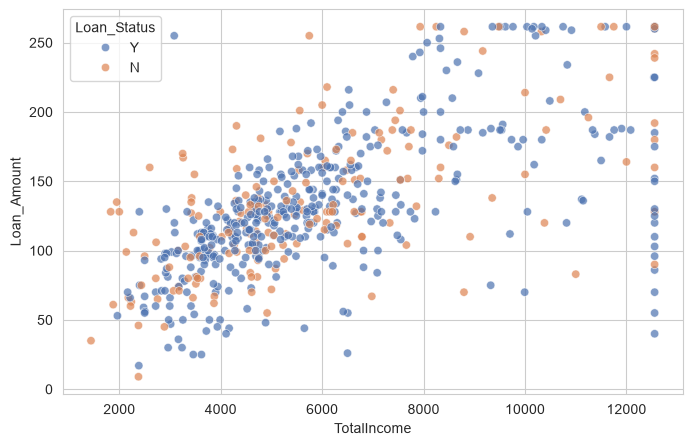

In [11]:
plt.figure()
sns.scatterplot(data=df, x="TotalIncome", y="Loan_Amount", hue="Loan_Status", palette=COLORS, alpha=0.7)
plt.savefig("../visuals/05_scatter_income_loanamount.png", bbox_inches="tight")
plt.show()

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_32112\2675753907.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Education", y="Loan_Amount", palette=COLORS)


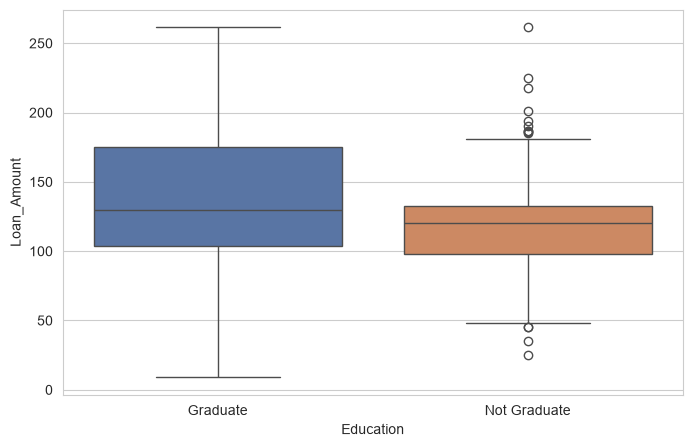

In [12]:
plt.figure()
sns.boxplot(data=df, x="Education", y="Loan_Amount", palette=COLORS)
plt.savefig("../visuals/06_box_loanamount_by_education.png", bbox_inches="tight")
plt.show()

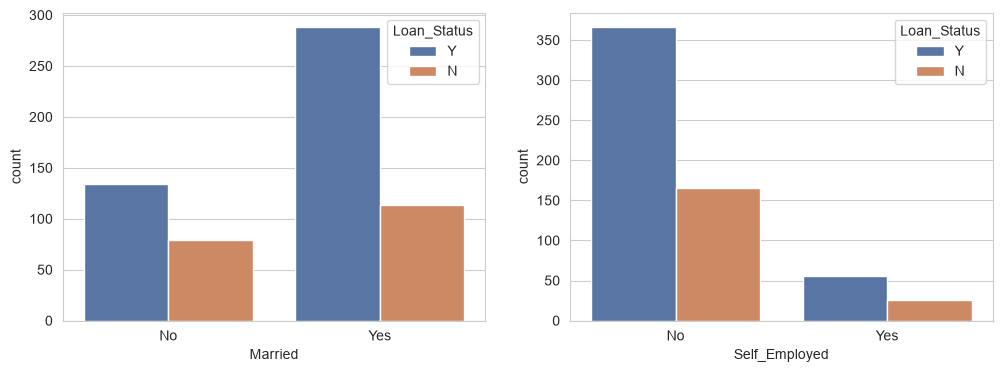

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="Married", hue="Loan_Status", palette=COLORS, ax=axes[0])
sns.countplot(data=df, x="Self_Employed", hue="Loan_Status", palette=COLORS, ax=axes[1])
plt.savefig("../visuals/07_married_selfemployed_vs_status.png", bbox_inches="tight")
plt.show()

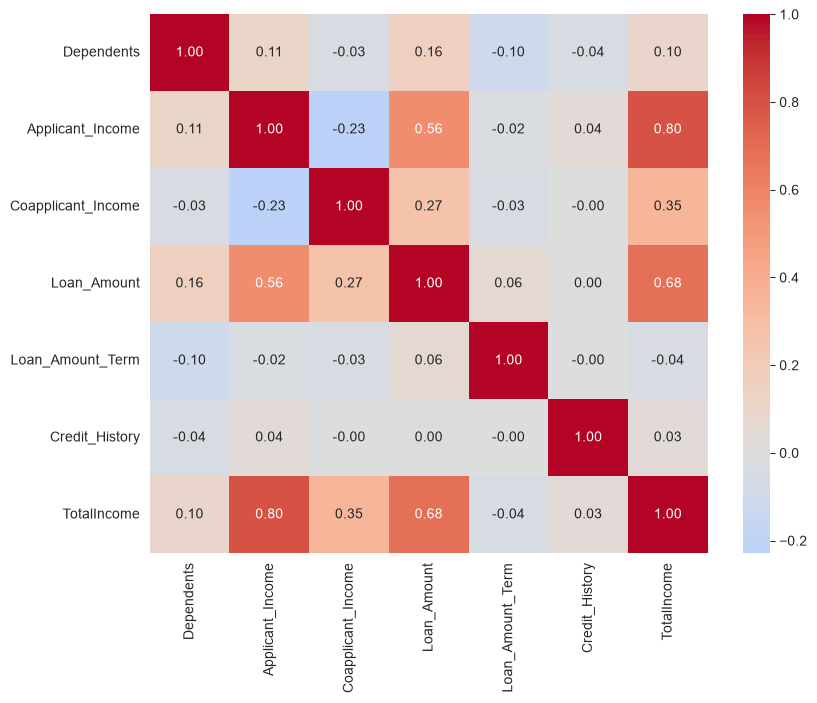

In [14]:
plt.figure(figsize=(9, 7))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.savefig("../visuals/08_correlation_heatmap.png", bbox_inches="tight")
plt.show()

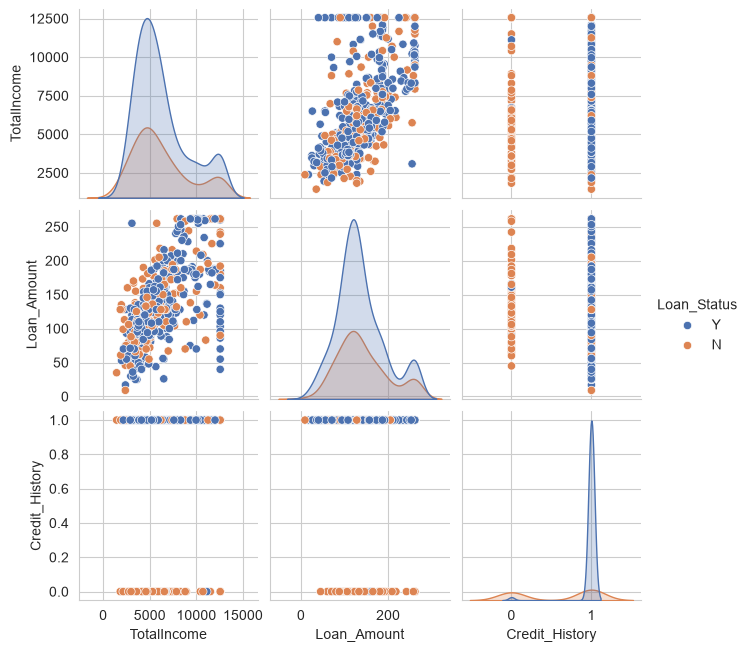

In [15]:
pair_cols = ["TotalIncome", "Loan_Amount", "Credit_History", "Loan_Status"]
g = sns.pairplot(df[pair_cols], hue="Loan_Status", palette=COLORS, diag_kind="kde", height=2.2)
g.savefig("../visuals/09_pairplot.png", bbox_inches="tight")
plt.show()

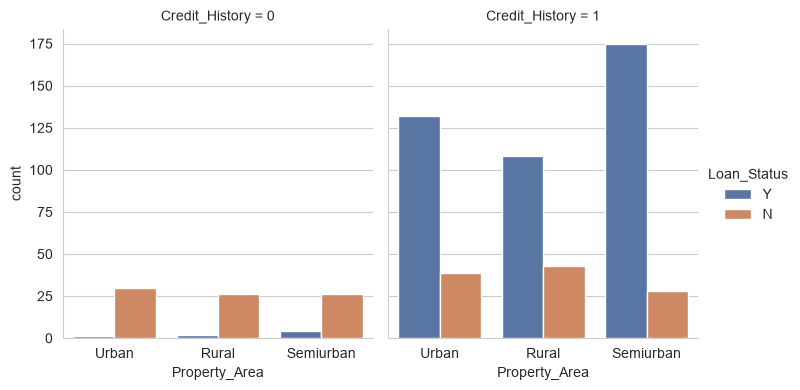

In [16]:
sns.catplot(data=df, x="Property_Area", hue="Loan_Status", col="Credit_History",
            kind="count", palette=COLORS, height=4, aspect=0.9)
plt.savefig("../visuals/10_grouped_credit_area_status.png", bbox_inches="tight")
plt.show()

In [17]:
df.pivot_table(index="Property_Area", columns="Loan_Status", values="TotalIncome", aggfunc="median")

Loan_Status,N,Y
Property_Area,,
Rural,5754.0,5703.5
Semiurban,5000.0,5262.0
Urban,5049.0,5318.0


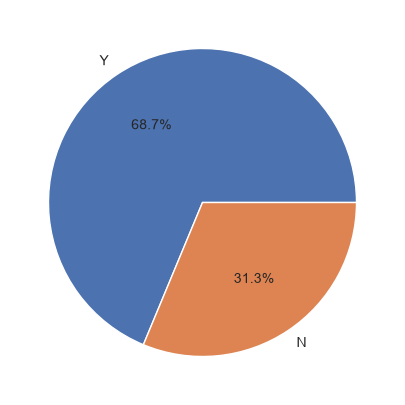

In [18]:
plt.figure()
df["Loan_Status"].value_counts().plot.pie(autopct="%1.1f%%", colors=COLORS, ylabel="")
plt.savefig("../visuals/11_class_distribution.png", bbox_inches="tight")
plt.show()

## Part 3 – Statistical Hypothesis Testing

**Test 1 — Pearson correlation: TotalIncome x Loan_Amount**

In [19]:
r, p = stats.pearsonr(df["TotalIncome"], df["Loan_Amount"])
r, p

(np.float64(0.6849099125344575), np.float64(3.3531502192999494e-86))

H0: r = 0. H1: r ≠ 0. Result: significant, moderate positive correlation.

**Test 2 — Chi-Square: Credit_History x Loan_Status**

In [20]:
ct1 = pd.crosstab(df["Credit_History"], df["Loan_Status"])
chi2, p2, dof, exp = stats.chi2_contingency(ct1)
chi2, p2

(np.float64(176.1145746235241), np.float64(3.4183499979091188e-40))

H0: independent. H1: associated. Result: p < 0.001, reject H0.

**Test 3 — Chi-Square: Property_Area x Loan_Status**

In [21]:
ct2 = pd.crosstab(df["Property_Area"], df["Loan_Status"])
chi2b, p3, dofb, expb = stats.chi2_contingency(ct2)
chi2b, p3

(np.float64(12.297623130485675), np.float64(0.0021360187811644937))

H0: independent. H1: associated. Result: p < 0.05, reject H0.

**Test 4 — Independent T-Test: TotalIncome by Loan_Status**

In [22]:
inc_y = df.loc[df["Loan_Status"] == "Y", "TotalIncome"]
inc_n = df.loc[df["Loan_Status"] == "N", "TotalIncome"]
t_stat, p4 = stats.ttest_ind(inc_y, inc_n, equal_var=False)
t_stat, p4

(np.float64(0.05322162414031196), np.float64(0.9575862866587763))

H0: equal means. H1: unequal means. Result: p > 0.05, fail to reject H0.

**Test 5 — Mann-Whitney U: Loan_Amount by Loan_Status**

In [23]:
loan_y = df.loc[df["Loan_Status"] == "Y", "Loan_Amount"]
loan_n = df.loc[df["Loan_Status"] == "N", "Loan_Amount"]
u_stat, p5 = stats.mannwhitneyu(loan_y, loan_n, alternative="two-sided")
u_stat, p5

(np.float64(38763.0), np.float64(0.3907257367725001))

H0: same distribution. H1: different distributions. Result: p > 0.05, fail to reject H0.

## Part 4 – Feature Engineering

In [24]:
df_fe = df.copy()

df_fe["Debt_to_Income_Ratio"] = df_fe["Loan_Amount"] / (df_fe["TotalIncome"] / 1000)
df_fe["Family_Size"] = df_fe["Dependents"] + df_fe["Married"].map({"Yes": 1, "No": 0}) + 1
df_fe["Balance_Income"] = (df_fe["TotalIncome"] / 12) - ((df_fe["Loan_Amount"] / df_fe["Loan_Amount_Term"]) * 1000 / 12)

median_dti = df_fe["Debt_to_Income_Ratio"].median()
df_fe["Credit_Risk_Category"] = np.where(
    df_fe["Credit_History"] == 0, "High Risk",
    np.where(df_fe["Debt_to_Income_Ratio"] > median_dti, "Medium Risk", "Low Risk")
)

df_fe[["Debt_to_Income_Ratio", "Family_Size", "Balance_Income", "Credit_Risk_Category"]].head()

,Debt_to_Income_Ratio,Family_Size,Balance_Income,Credit_Risk_Category
0,21.884083,1,457.787037,Low Risk
1,21.014612,3,477.953704,Low Risk
2,22.000000,2,234.722222,Low Risk
3,24.286582,2,383.972222,Medium Risk
4,23.500000,1,467.361111,Low Risk


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_32112\620748433.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fe, x="Loan_Status", y="Debt_to_Income_Ratio", palette=COLORS)


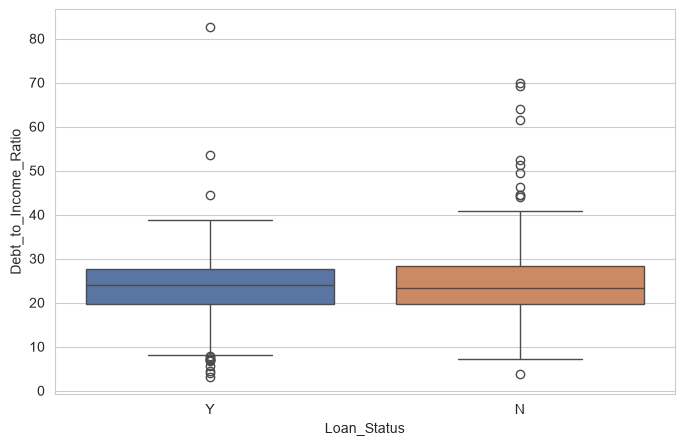

In [ ]:
plt.figure()
sns.boxplot(data=df_fe, x="Loan_Status", y="Debt_to_Income_Ratio", palette=COLORS)
plt.savefig("../visuals/12_dti_by_status.png", bbox_inches="tight")
plt.show()

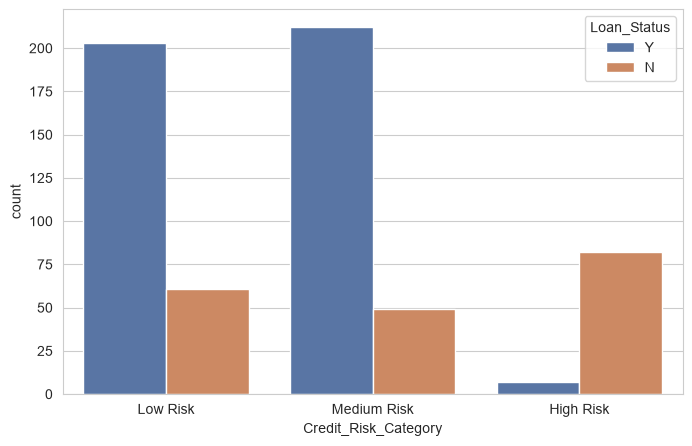

In [26]:
plt.figure()
sns.countplot(data=df_fe, x="Credit_Risk_Category", hue="Loan_Status", palette=COLORS,
              order=["Low Risk", "Medium Risk", "High Risk"])
plt.savefig("../visuals/13_credit_risk_vs_status.png", bbox_inches="tight")
plt.show()

## Part 5 – Feature Evaluation and Selection

In [27]:
tmp = df_fe.copy()
tmp["Loan_Status_num"] = tmp["Loan_Status"].map({"Y": 1, "N": 0})
tmp.select_dtypes(include=[np.number]).corr()["Loan_Status_num"].sort_values(ascending=False)

Loan_Status_num         1.000000
Credit_History          0.540556
Family_Size             0.042963
Coapplicant_Income      0.011983
Dependents              0.010118
Balance_Income          0.004729
TotalIncome             0.002220
Applicant_Income       -0.000442
Loan_Amount_Term       -0.022549
Loan_Amount            -0.047262
Debt_to_Income_Ratio   -0.103665
Name: Loan_Status_num, dtype: float64

In [28]:
df_final = df_fe.drop(columns=["Applicant_Income", "Coapplicant_Income", "Loan_Amount_Term"])
df_final.columns.tolist()

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Loan_Amount',
 'Credit_History',
 'Property_Area',
 'Loan_Status',
 'TotalIncome',
 'Debt_to_Income_Ratio',
 'Family_Size',
 'Balance_Income',
 'Credit_Risk_Category']

## Part 6 – Dataset Refinement and ML Preparation

In [29]:
df_final.to_csv("../data/processed/loan_final_cleaned_w3.csv", index=False)
df_final.shape

(614, 14)

In [30]:
df_ml = df_final.copy()
label_cols = ["Gender", "Married", "Education", "Self_Employed", "Loan_Status"]
le = LabelEncoder()
for col in label_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml = pd.get_dummies(df_ml, columns=["Property_Area", "Credit_Risk_Category"], drop_first=True)

numeric_cols = ["TotalIncome", "Loan_Amount", "Debt_to_Income_Ratio", "Balance_Income", "Family_Size", "Dependents"]
scaler = StandardScaler()
df_ml[numeric_cols] = scaler.fit_transform(df_ml[numeric_cols])

df_ml.to_csv("../data/processed/loan_ml_ready_w3.csv", index=False)
df_ml.shape

(614, 16)